# Приклад виконання в Python

Нижче наведено приклад моделювання AM та FM, а також спрощеної демодуляції AM-сигналу методом виділення огинаючої

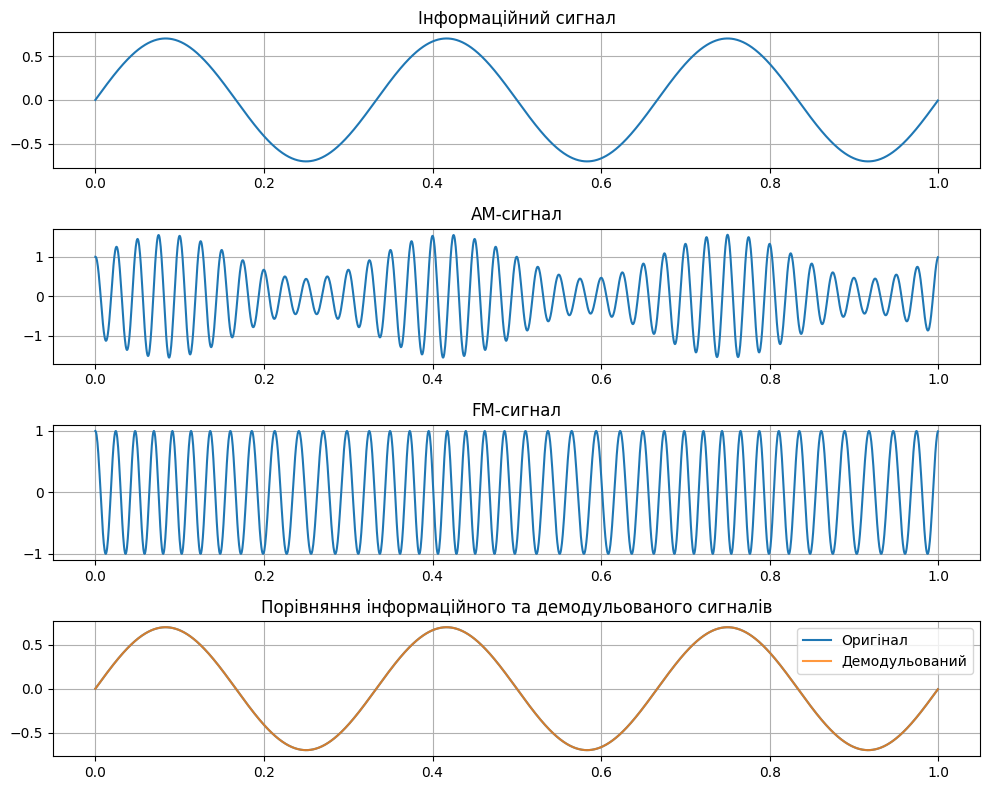

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Параметри часу
fs = 2000
t = np.arange(0, 1, 1 / fs)

# Інформаційний сигнал
fm = 3
m = 0.7 * np.sin(2 * np.pi * fm * t)

# Несуча
fc = 40
Ac = 1.0
carrier = Ac * np.cos(2 * np.pi * fc * t)

# AM-модуляція
ka = 0.8
am_signal = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# FM-модуляція
kf = 8
integral_m = np.cumsum(m) / fs
fm_signal = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# Демодуляція AM через огинаючу
analytic = hilbert(am_signal)
envelope = np.abs(analytic)
demod = (envelope - np.mean(envelope)) / ka

# Графіки
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(t, m)
plt.title("Інформаційний сигнал")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, am_signal)
plt.title("AM-сигнал")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, fm_signal)
plt.title("FM-сигнал")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, m, label="Оригінал")
plt.plot(t, demod, label="Демодульований", alpha=0.8)
plt.title("Порівняння інформаційного та демодульованого сигналів")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


*Пояснення до прикладу на Python*

•	Hilbert-перетворення дозволяє побудувати аналітичний сигнал і отримати огинаючу AM-сигналу.

•	Для FM у коді використано чисельне інтегрування модулюючого сигналу через накопичену суму.

•	Демодульований сигнал порівнюється з оригінальним повідомленням, що дозволяє оцінити похибку відновлення.


Індивідуальні завдання
1. Змінити коефіцієнт амплітудної модуляції k_a і дослідити випадки μ < 1, μ = 1 та μ > 1.
2. Побудувати спектр AM-сигналу для двох різних частот модулюючого сигналу.
3. Реалізувати PM-сигнал і порівняти його з FM для однакового повідомлення.
4. Додати шум до AM-сигналу і оцінити якість демодуляції.
5. Порівняти результати демодуляції при різній частоті дискретизації.
6. Реалізувати двотональний модулюючий сигнал та проаналізувати, як змінюється спектр модульованого сигналу.
7. Виконати порівняння AM і FM за критеріями спектральної ширини та стійкості до амплітудного шуму.
8. Побудувати графік миттєвої фази або миттєвої частоти для FM/PM-сигналу.


#Реалізація завдань

## 1.Змінити коефіцієнт амплітудної модуляції k_a і дослідити випадки μ < 1, μ = 1 та μ > 1.

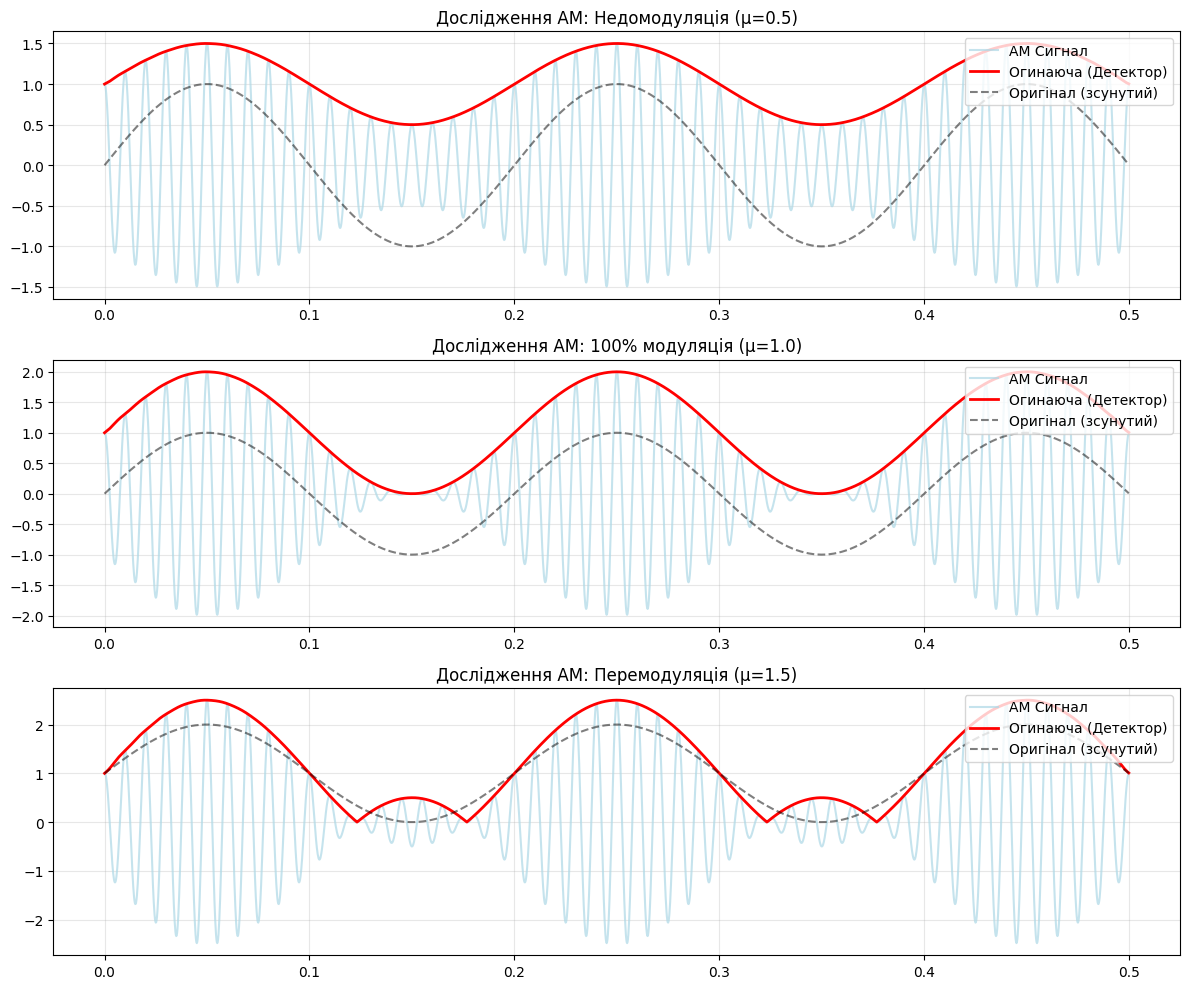

 Коефіцієнт ka                   Стан  Похибка MSE
           0.5  Недомодуляція (μ=0.5)     0.000004
           1.0 100% модуляція (μ=1.0)     0.000004
           1.5  Перемодуляція (μ=1.5)     0.064177


In [2]:
# 1. Змінити коефіцієнт амплітудної модуляції k_a і дослідити випадки μ < 1, μ = 1 та μ > 1.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import hilbert


def calculate_mse(orig, demod):
    """Обчислює середньоквадратичну похибку між оригіналом та демодульованим сигналом"""
    # Нормалізуємо обидва сигнали для чесного порівняння
    orig_norm = (orig - np.mean(orig)) / np.std(orig)
    demod_norm = (demod - np.mean(demod)) / np.std(demod)
    return np.mean((orig_norm - demod_norm)**2)

def study_am(ka_index):
    # 1. Параметри
    fs = 5000
    t = np.arange(0, 0.5, 1 / fs) # пів секунди для наочності
    fc = 100
    fm = 5
    Ac = 1.0

    # Інформаційний сигнал (нормалізований до 1, щоб ka став індексом модуляції)
    m = np.sin(2 * np.pi * fm * t)

    # 2. АМ Модуляція
    # Формула: s(t) = Ac * [1 + ka * m(t)] * cos(2*pi*fc*t)
    am_signal = Ac * (1 + ka_index * m) * np.cos(2 * np.pi * fc * t)

    # 3. Демодуляція (виділення огинаючої через перетворення Гільберта)
    analytic_signal = hilbert(am_signal)
    envelope = np.abs(analytic_signal)

    # Відновлюємо сигнал (прибираємо постійну складову Ac)
    demodulated = envelope - np.mean(envelope)

    # 4. Розрахунок похибки
    error = calculate_mse(m, demodulated)

    return t, m, am_signal, envelope, error

ka_values = [0.5, 1.0, 1.5] # μ < 1, μ = 1, μ > 1
labels = ["Недомодуляція (μ=0.5)", "100% модуляція (μ=1.0)", "Перемодуляція (μ=1.5)"]

results_am = []
plt.figure(figsize=(12, 10))

for i, ka in enumerate(ka_values):
    t, m, am, env, err = study_am(ka)

    results_am.append({
        "Коефіцієнт ka": ka,
        "Стан": labels[i],
        "Похибка MSE": round(err, 6)
    })

    # Графіки
    plt.subplot(3, 1, i+1)
    plt.plot(t, am, color='lightblue', label='AM Сигнал', alpha=0.7)
    plt.plot(t, env, color='red', linewidth=2, label='Огинаюча (Детектор)')
    plt.plot(t, m + 1 if ka > 1 else m, color='black', linestyle='--', alpha=0.5, label='Оригінал (зсунутий)')
    plt.title(f"Дослідження AM: {labels[i]}")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вивід таблиці
df_am = pd.DataFrame(results_am)
print(df_am.to_string(index=False))

**Спостереження:**

	-  μ < 1, k_a=0.5   - червона лінія плавно повторює форму синусоїди, похибка мінімальна.

	- μ = 1, k_a=1 – огинаюча (червона лінія) торкається горизонтальної осі (нуля) в точках мінімуму, це межа роботи детектора.

	- μ > 1, k_a=1.5 – в нижній частині синусоїда мала б бути менше нуля, але детектор огинаючої завжди додатний, з’являються додаткові горбочки; похибка зростає.


## 2.Побудувати спектр AM-сигналу для двох різних частот модулюючого сигналу.

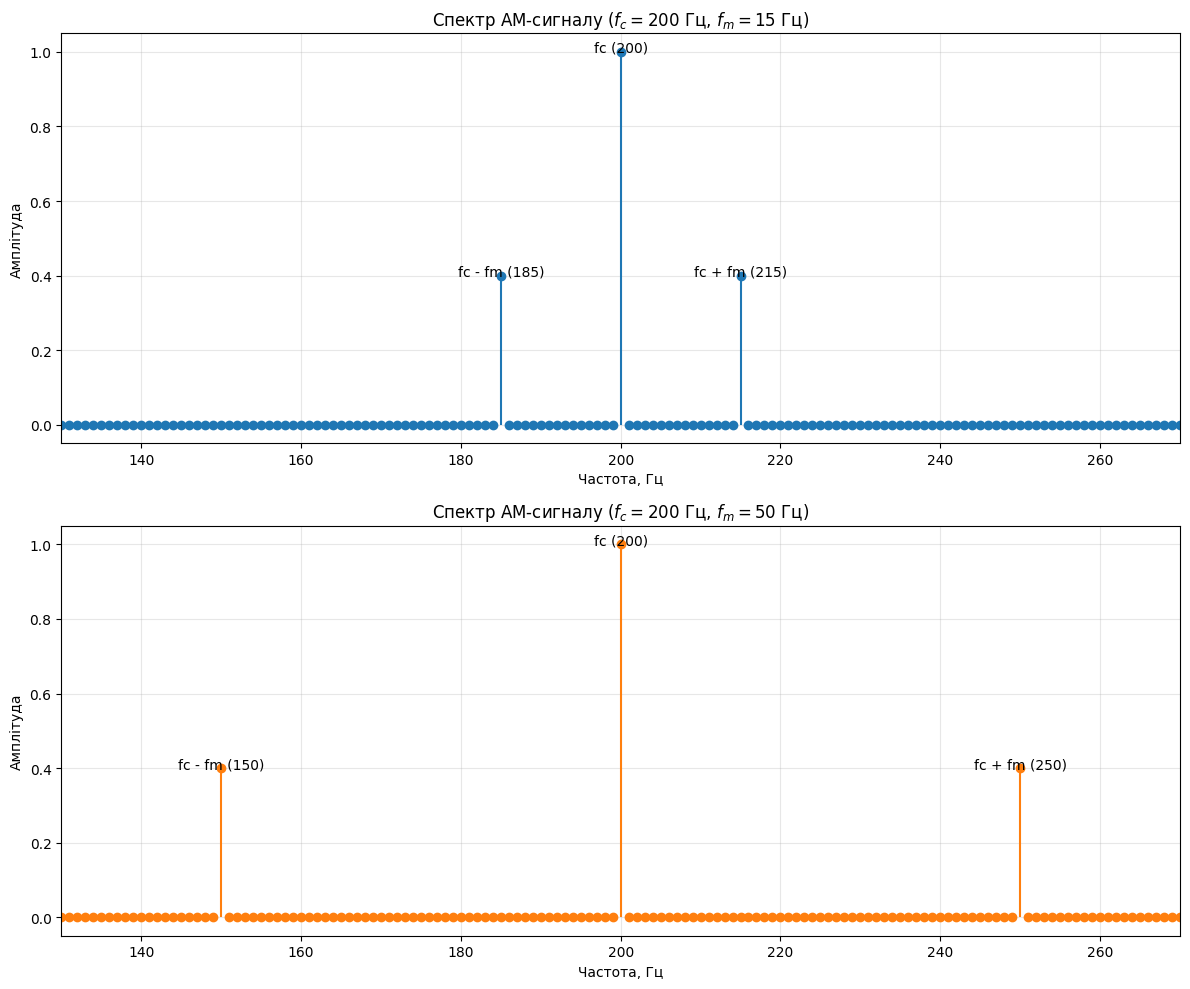

In [3]:
# 2. Побудувати спектр AM-сигналу для двох різних частот модулюючого сигналу.
def get_spectrum(signal, fs):
    """Обчислює амплітудний спектр сигналу"""
    n = len(signal)
    # Обчислюємо FFT
    fft_vals = np.fft.fft(signal)
    # Отримуємо частотну вісь
    freqs = np.fft.fftfreq(n, 1/fs)
    # Беремо лише позитивні частоти та нормалізуємо амплітуду
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# Параметри
fs = 2000          # Частота дискретизації
t = np.arange(0, 1, 1/fs)
fc = 200           # Несуча частота (200 Гц)
ka = 0.8           # Коефіцієнт модуляції

# Дві різні частоти повідомлення
fm1 = 15           # 15 Гц
fm2 = 50           # 50 Гц

# Генерація сигранів
m1 = np.sin(2 * np.pi * fm1 * t)
am1 = (1 + ka * m1) * np.cos(2 * np.pi * fc * t)

m2 = np.sin(2 * np.pi * fm2 * t)
am2 = (1 + ka * m2) * np.cos(2 * np.pi * fc * t)

# Обчислення спектрів
f1, spec1 = get_spectrum(am1, fs)
f2, spec2 = get_spectrum(am2, fs)

# Візуалізація
plt.figure(figsize=(12, 10))

# Спектр 1
plt.subplot(2, 1, 1)
plt.stem(f1, spec1, basefmt=" ", markerfmt="C0o", linefmt="C0-")
plt.title(f"Спектр АМ-сигналу ($f_c=200$ Гц, $f_m={fm1}$ Гц)")
plt.xlim(130, 270) # Обмежуємо вісь для детального вигляду навколо fc
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Підписи до піків
plt.annotate(f'fc - fm ({fc-fm1})', xy=(fc-fm1, 0.4), ha='center')
plt.annotate(f'fc ({fc})', xy=(fc, 1.0), ha='center')
plt.annotate(f'fc + fm ({fc+fm1})', xy=(fc+fm1, 0.4), ha='center')

# Спектр 2
plt.subplot(2, 1, 2)
plt.stem(f2, spec2, basefmt=" ", markerfmt="C1o", linefmt="C1-")
plt.title(f"Спектр АМ-сигналу ($f_c=200$ Гц, $f_m={fm2}$ Гц)")
plt.xlim(130, 270)
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Підписи до піків
plt.annotate(f'fc - fm ({fc-fm2})', xy=(fc-fm2, 0.4), ha='center')
plt.annotate(f'fc ({fc})', xy=(fc, 1.0), ha='center')
plt.annotate(f'fc + fm ({fc+fm2})', xy=(fc+fm2, 0.4), ha='center')

plt.tight_layout()
plt.show()

**Спостереження:**

На обох графіках центральний пік розташований на частоті 200Гц – несуча частота, має найвищу амплітуду.

На першому графіку f_m=15, бічні піки на частотах 185Гц і 215Гц, ширина смуги – 30Гц.

На другому графіку f_m=50, бічні піки на частотах 150Гц і 250Гц, ширина смуги – 100Гц.

Зі збільшенням частоти модулюючого сигналу бокові компоненти спектра віддаляються від несучої частоти.

Ширина спектра, яку займає АМ-сигнал, прямо пропорційна частоті і рівна 2f_m


## 3.Реалізувати PM-сигнал і порівняти його з FM для однакового повідомлення.




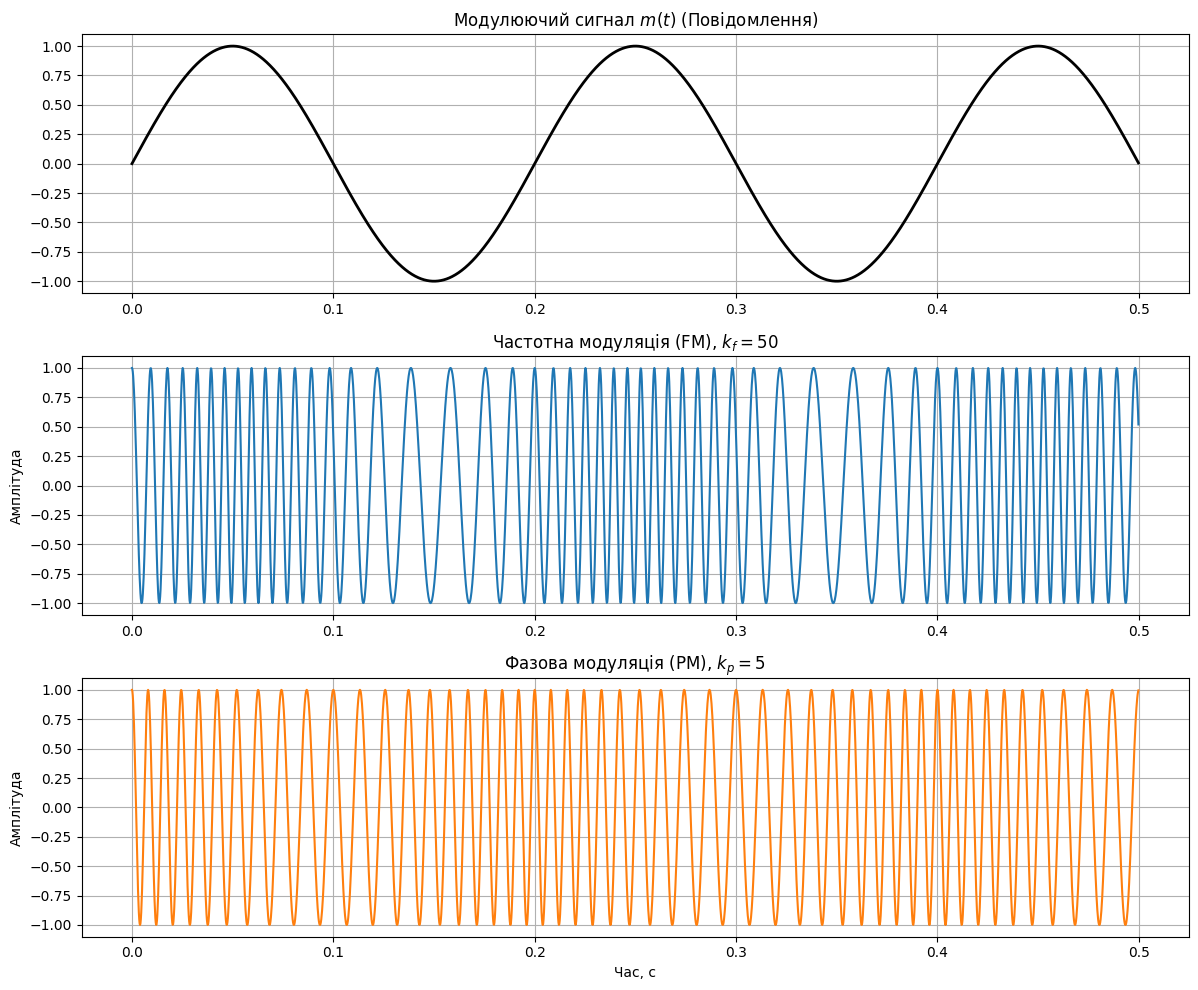

In [4]:
# 3.Реалізувати PM-сигнал і порівняти його з FM для однакового повідомлення.

# Параметри
fs = 5000         # Частота дискретизації
t = np.arange(0, 0.5, 1/fs)
fc = 100          # Несуча частота (100 Гц)
fm = 5            # Частота повідомлення (5 Гц)
Ac = 1.0

# Інформаційний сигнал (синусоїда)
m = np.sin(2 * np.pi * fm * t)

# FM модуляція
kf = 50           # Чутливість по частоті (девіація)
# Фаза для FM - це інтеграл від повідомлення
integral_m = np.cumsum(m) / fs
fm_signal = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# PM Ммодуляція
kp = 5            # Чутливість по фазі (індекс модуляції)
# Фаза для PM змінюється прямо за m(t)
pm_signal = Ac * np.cos(2 * np.pi * fc * t + kp * m)

# Візуалізація
plt.figure(figsize=(12, 10))

# Повідомлення
plt.subplot(3, 1, 1)
plt.plot(t, m, 'k', linewidth=2)
plt.title("Модулюючий сигнал $m(t)$ (Повідомлення)")
plt.grid(True)

# FM Сигнал
plt.subplot(3, 1, 2)
plt.plot(t, fm_signal, 'C0')
plt.title(f"Частотна модуляція (FM), $k_f={kf}$")
plt.ylabel("Амплітуда")
plt.grid(True)

# PM Сигнал
plt.subplot(3, 1, 3)
plt.plot(t, pm_signal, 'C1')
plt.title(f"Фазова модуляція (PM), $k_p={kp}$")
plt.ylabel("Амплітуда")
plt.xlabel("Час, с")
plt.grid(True)

plt.tight_layout()
plt.show()

**Спостереження:**

У частотній модуляції (FM):

- максимальне стиснення відбувається тоді, коли m(t) має максимальне значення.

- мінімальна частота (найбільше розтягнення), коли m(t) – мінімальне.

У фазовій модуляції  (РМ):

- максимальне стиснення відбувається в точках, де похідна модулюючого сигналу максимальна.

- якщо m(t) синусоїда, то РМ-сигнал виглядає як FM-сигнал, зсунутий за фазою на 90 градусів.



## 4.Додати шум до AM-сигналу і оцінити якість демодуляції.

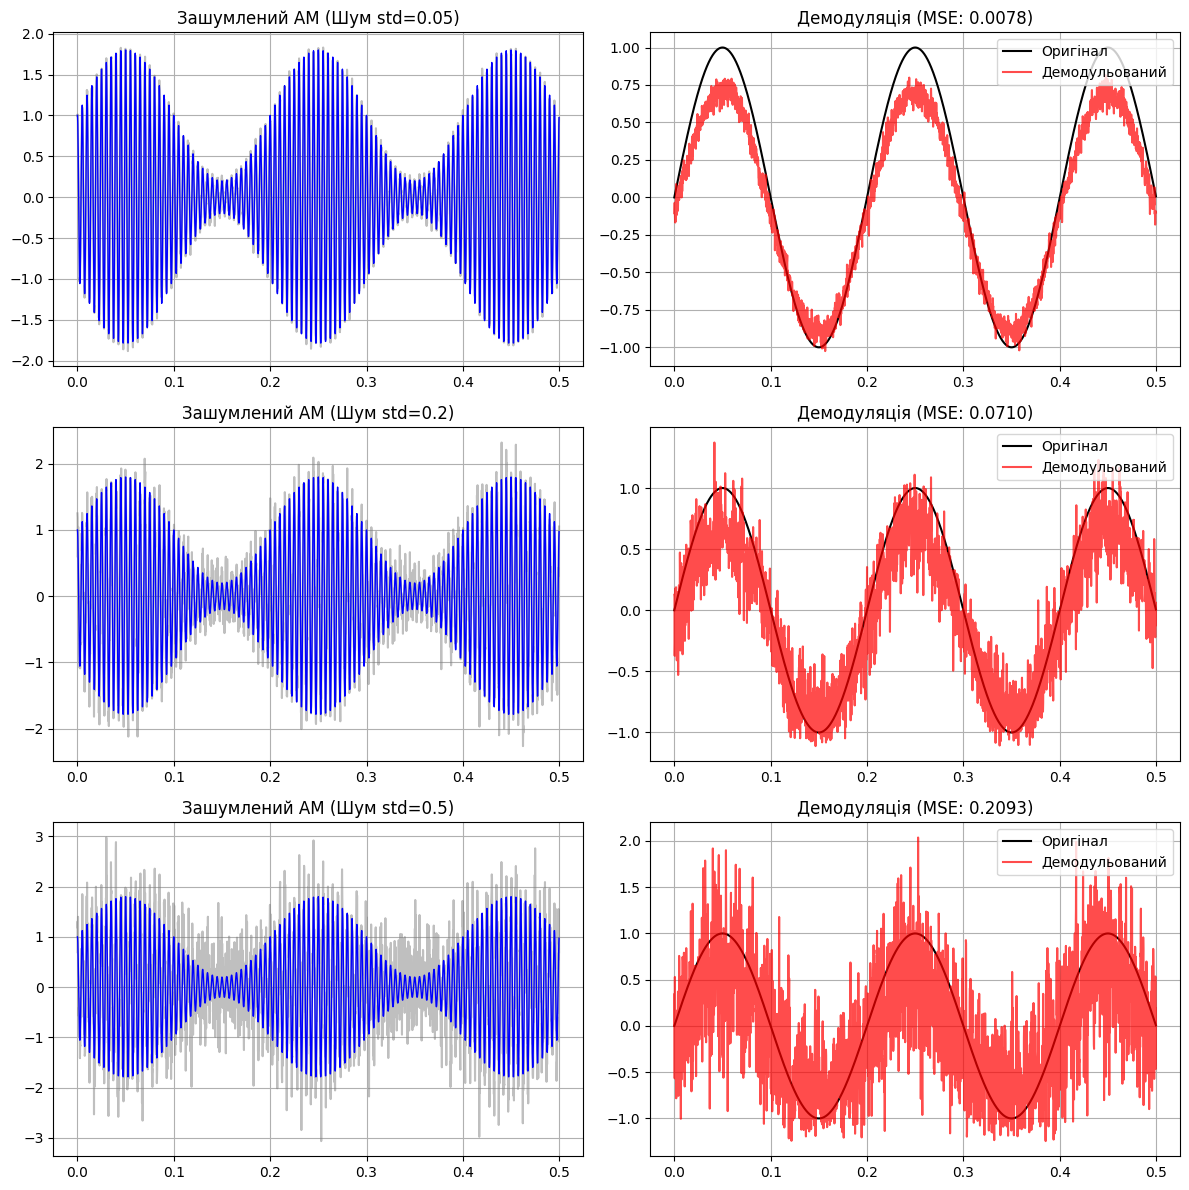

In [5]:
# 4. Додати шум до AM-сигналу і оцінити якість демодуляції.
from scipy.signal import hilbert

def calculate_mse(orig, demod):
    """Обчислює середньоквадратичну похибку (MSE) після нормалізації"""
    # Нормалізація обох сигналів до діапазону [-1, 1] для чесного порівняння
    orig_n = (orig - np.mean(orig)) / np.max(np.abs(orig - np.mean(orig)))
    demod_n = (demod - np.mean(demod)) / np.max(np.abs(demod - np.mean(demod)))
    return np.mean((orig_n - demod_n)**2)

# Параметри
fs = 5000
t = np.arange(0, 0.5, 1/fs)
fc = 200
fm = 5
ka = 0.8
Ac = 1.0

# 1. Створення чистого АМ-сигналу
m = np.sin(2 * np.pi * fm * t)
am_clean = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# 2. Додавання шуму (різні рівні)
noise_levels = [0.05, 0.2, 0.5] # Стандартне відхилення шуму
results = []

plt.figure(figsize=(12, 12))

for i, std in enumerate(noise_levels):
    # Додаємо білий гауссів шум
    noise = np.random.normal(0, std, len(am_clean))
    am_noisy = am_clean + noise

    # 3. Демодуляція через огинаючу (Гільберт)
    envelope = np.abs(hilbert(am_noisy))
    demod = envelope - np.mean(envelope) # Прибираємо постійну складову

    # Розрахунок похибки
    mse = calculate_mse(m, demod)
    results.append(mse)

    # Графіки
    plt.subplot(len(noise_levels), 2, 2*i + 1)
    plt.plot(t, am_noisy, color='gray', alpha=0.5)
    plt.plot(t, am_clean, color='blue', linewidth=1, label='Чистий АМ')
    plt.title(f"Зашумлений АМ (Шум std={std})")
    plt.grid(True)

    plt.subplot(len(noise_levels), 2, 2*i + 2)
    plt.plot(t, m, 'k', label='Оригінал')
    plt.plot(t, demod, 'r', alpha=0.7, label='Демодульований')
    plt.title(f"Демодуляція (MSE: {mse:.4f})")
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()

**Спостереження:**

1.	Низький рівень шуму: АМ-сигнал виглядає злегка кошлатим, демодульована синусоїда має незначні тремтіння, форма впізнавана, MSE низький
2.	Середній рівень шуму: шум стає помітним, після демодуляції синусоїда з виразним накладенимм шумом.
3.	Високий рівень шуму: АМ-сигнал сильна спотворений, демодульований сигнал ледь нагадує оригінал, MSE значно зростає.


## 5.Порівняти результати демодуляції при різній частоті дискретизації.

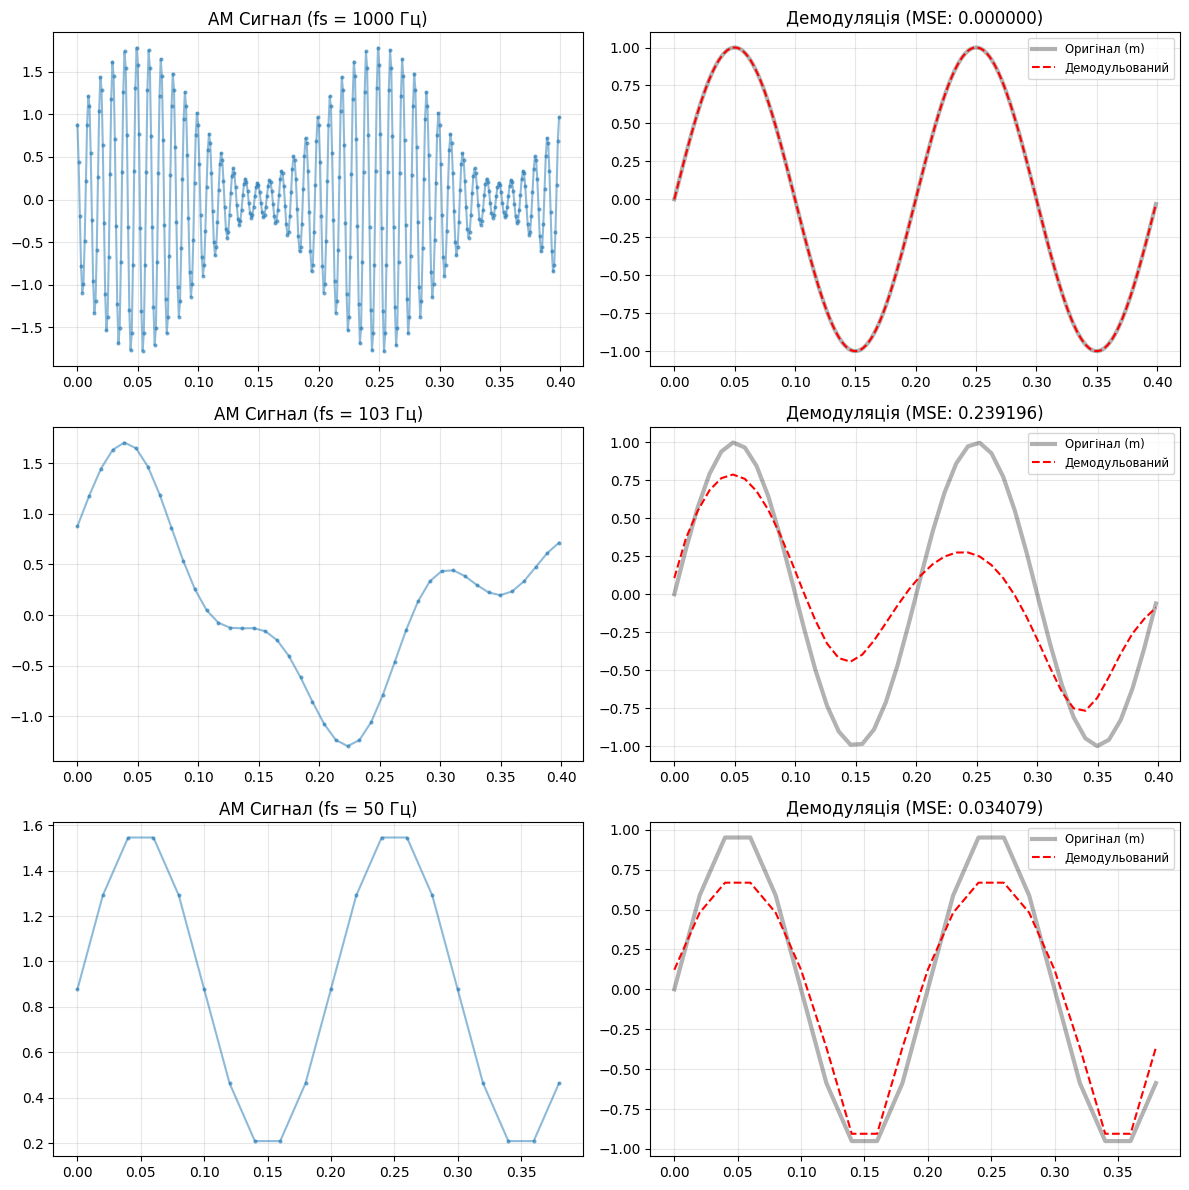

In [6]:
# 5. Порівняти результати демодуляції при різній частоті дискретизації.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def calculate_mse(orig, demod):
    # Нормалізація
    orig_n = (orig - np.mean(orig)) / np.std(orig)
    demod_n = (demod - np.mean(demod)) / np.std(demod)
    return np.mean((orig_n - demod_n)**2)

# Параметри
fc = 100    # Несуча
fm = 5      # Повідомлення
ka = 0.8
duration = 0.4

fs_values = [1000, 103, 50]

plt.figure(figsize=(12, 12))

for i, fs in enumerate(fs_values):
    t = np.arange(0, duration, 1/fs)

    # Додаємо невеликий зсув фази
    m = np.sin(2 * np.pi * fm * t)
    am_signal = (1 + ka * m) * np.cos(2 * np.pi * fc * t + 0.5)

    # Демодуляція
    analytic = hilbert(am_signal)
    envelope = np.abs(analytic)
    demod = (envelope - np.mean(envelope)) / ka

    mse = calculate_mse(m, demod)

    # ГРАФІК 1: СИГНАЛ (точки)
    plt.subplot(len(fs_values), 2, 2*i + 1)
    plt.plot(t, am_signal, 'C0.-', alpha=0.5, markersize=4, label='Samples')
    plt.title(f"AM Сигнал (fs = {fs} Гц)")
    plt.grid(True, alpha=0.3)

    # ГРАФІК 2: ПОРІВНЯННЯ
    plt.subplot(len(fs_values), 2, 2*i + 2)
    plt.plot(t, m, 'k', linewidth=3, label='Оригінал (m)', alpha=0.3)
    plt.plot(t, demod, 'r--', linewidth=1.5, label='Демодульований')
    plt.title(f"Демодуляція (MSE: {mse:.6f})")
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Спостереження:**

- f_s=1000 Гц, MSE≈0: частота дискретизації у 10 разів вища за частоту несучої. Результатом є ідеальна демодуляція.

- f_s=103 Гц, MSE≈0.239: найгірший результат, випадок аліасингу (накладання спектрів). Є найбільш показовим прикладом того, як неправильна дискретизація «вбиває» сигнал.

- f_s=50 Гц, MSE≈0.034: частота дискретизації рівно у два рази менше за несучу. Помилка виглядає непогано, але при такій частоті дискретизації несуча «відбивається» в 0 Гц, а сам сигнал фактично зруйнований.


## 6.Реалізувати двотональний модулюючий сигнал та проаналізувати, як змінюється спектр модульованого сигналу.

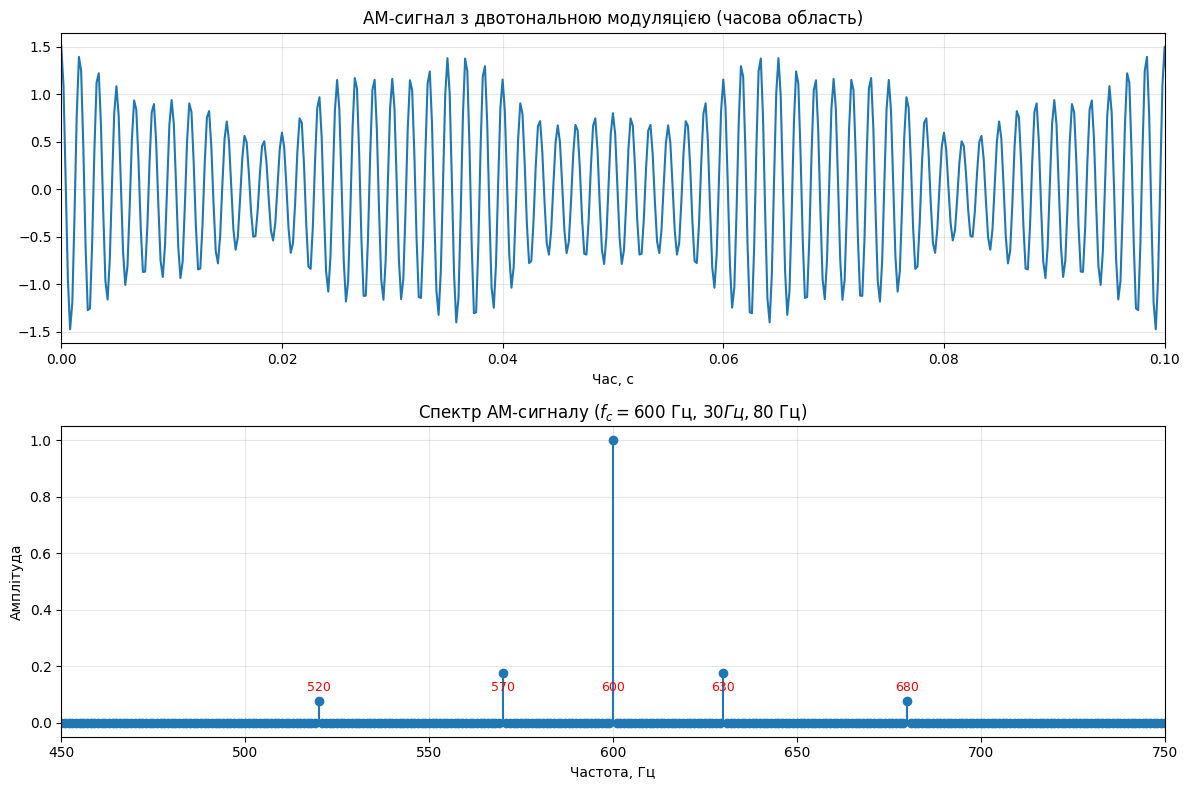

In [7]:
# 6. Реалізувати двотональний модулюючий сигнал та проаналізувати, як змінюється спектр модульованого сигналу.
import numpy as np
import matplotlib.pyplot as plt

def get_spectrum(signal, fs):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, 1/fs)
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# Параметри
fs = 5000
t = np.arange(0, 1, 1/fs)
fc = 600           # Несуча частота (600 Гц)
ka = 0.5           # Коефіцієнт модуляції

# Двотональний інформаційний сигнал (30 Гц та 80 Гц)
fm1 = 30
fm2 = 80
m = 0.7 * np.cos(2 * np.pi * fm1 * t) + 0.3 * np.cos(2 * np.pi * fm2 * t)

# АМ-модуляція
am_signal = (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# Обчислення спектру
f, spec = get_spectrum(am_signal, fs)

# Візуалізація
plt.figure(figsize=(12, 8))

# Часова область (зблизька)
plt.subplot(2, 1, 1)
plt.plot(t, am_signal)
plt.title("АМ-сигнал з двотональною модуляцією (часова область)")
plt.xlim(0, 0.1) # Показуємо перші 0.1 сек
plt.xlabel("Час, с")
plt.grid(True, alpha=0.3)

# Частотна область
plt.subplot(2, 1, 2)
plt.stem(f, spec, basefmt=" ", markerfmt="C0o")
plt.title(f"Спектр АМ-сигналу ($f_c=600$ Гц, {fm1}$ Гц, {fm2}$ Гц)")
plt.xlim(fc - 150, fc + 150) # Збільшуємо область навколо несучої
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Підписи піків
peaks = [fc, fc-fm1, fc+fm1, fc-fm2, fc+fm2]
for p in peaks:
    plt.annotate(f'{p}', xy=(p, 0.1), ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

**Спостереження:**

Центральна лінія несучої (600 Гц) та дві пари симетричних 570 Гц та 630 Гц, 520Гц та 680 Гц, амплітуда яких пропорційна амплітудам частот у модулюючому сигналі.

Амплітудна модуляція є лінійним процесом відносно спектру повідомлення. Кожна гармоніка моделюючого сигналу створює свою пару бічних смуг у спектрі АМ-сигналу.


## 7.Виконати порівняння AM і FM за критеріями спектральної ширини та стійкості до амплітудного шуму.

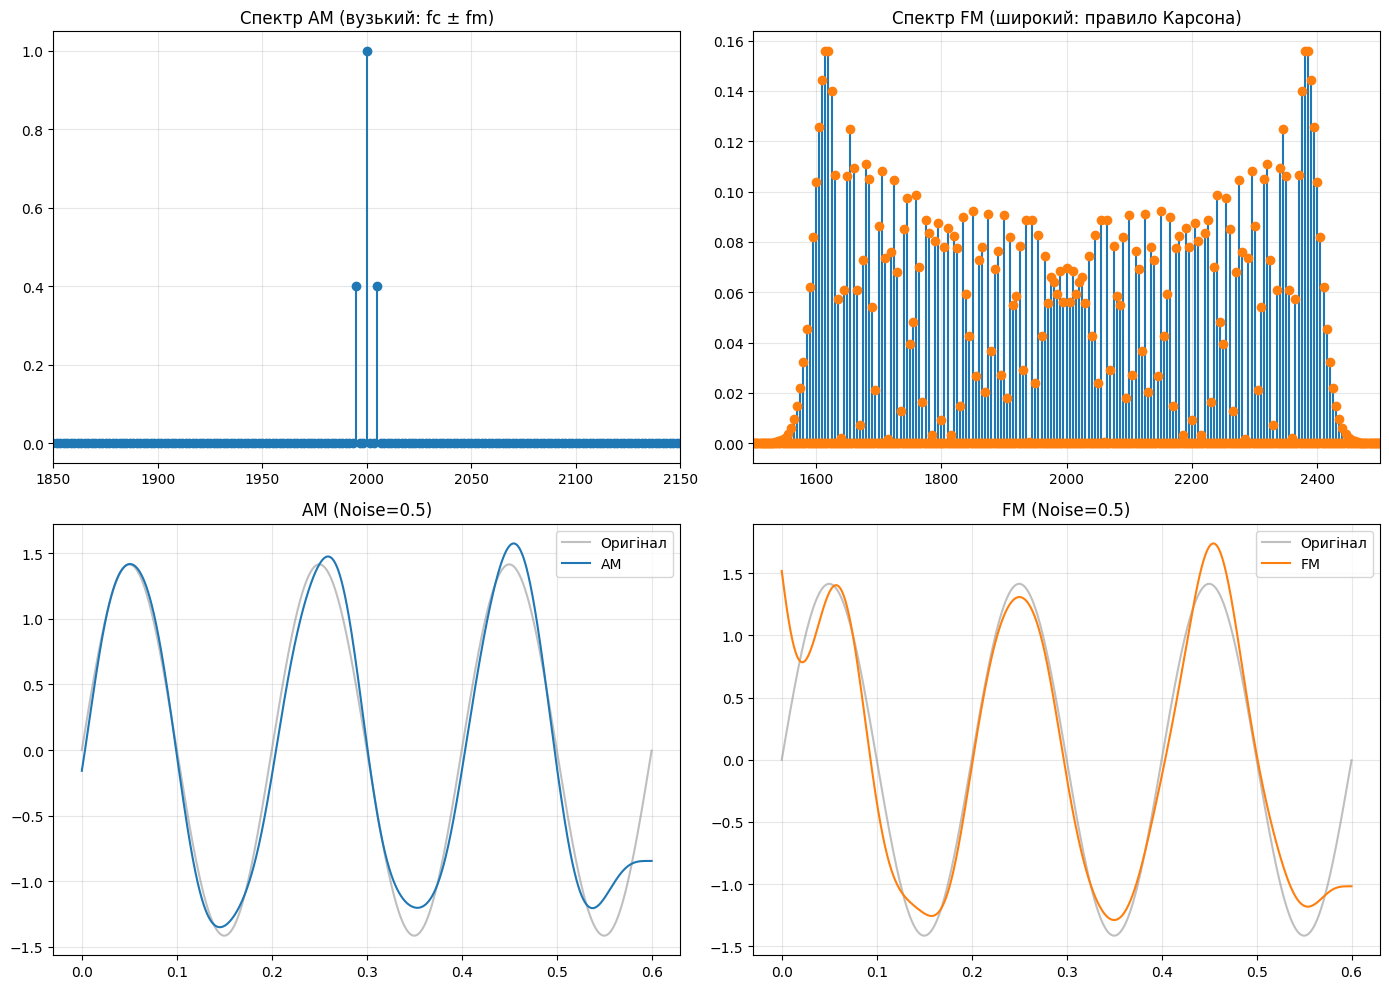

In [8]:
# 7. Виконати порівняння AM і FM за критеріями спектральної ширини та стійкості до амплітудного шуму.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt

# Фіксація генератора (для стабільності результатів)
np.random.seed(42)

# Параметри
fs = 10000          # Велика частота дискретизації для стабільності диференціювання
t = np.arange(0, 0.6, 1 / fs)
fc = 2000           # Несуча частота
fm = 5              # Частота повідомлення
Ac = 1.0
ka = 0.8
kf = 400            # Девіація

m = np.sin(2 * np.pi * fm * t)

# Модуляція
am_signal = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)
fm_signal = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * np.cumsum(m)/fs)

# Функції обробки
def get_lpf(cutoff, fs, order=4):
    return butter(order, cutoff / (0.5 * fs), btype='low')

def normalize(sig):
    """Стійке нормування для розрахунку MSE"""
    return (sig - np.mean(sig)) / np.std(sig)

def get_spectrum(signal, fs):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, 1/fs)
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# Дослідження для різних рівнів шуму
noise_levels = [0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5]
results = []

for std in noise_levels:
    noise = np.random.normal(0, std, len(t))

    # Демодуляція АМ
    am_noisy = am_signal + noise
    am_env = np.abs(hilbert(am_noisy))
    b, a = get_lpf(fm * 3, fs)
    am_demod = filtfilt(b, a, am_env - np.mean(am_env))

    # Демодуляція FM (з обмежувачем)
    fm_noisy = fm_signal + noise
    # Обмежувач: прибираємо шум в амплітуді перед Гільбертом
    fm_limited = fm_noisy / np.abs(hilbert(fm_noisy))

    analytic_fm = hilbert(fm_limited)
    phase = np.unwrap(np.angle(analytic_fm))
    # Диференціювання фази
    fm_demod_raw = np.diff(phase) / (2 * np.pi / fs)
    fm_demod_raw = np.append(fm_demod_raw, fm_demod_raw[-1]) - fc
    fm_demod = filtfilt(b, a, fm_demod_raw)

    # Розрахунок MSE (нормалізовані сигнали)
    mse_am = np.mean((normalize(m) - normalize(am_demod))**2)
    mse_fm = np.mean((normalize(m) - normalize(fm_demod))**2)

    results.append({
        "Noise Std": std,
        "MSE AM": round(mse_am, 5),
        "MSE FM": round(mse_fm, 5),
        "Winner": "FM" if mse_fm < mse_am else "AM"
    })

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Спектр AM
f_am, s_am = get_spectrum(am_signal, fs)
axes[0, 0].stem(f_am, s_am, basefmt=" ", markerfmt="C0o")
axes[0, 0].set_title("Спектр AM (вузький: fc ± fm)")
axes[0, 0].set_xlim(fc - 150, fc + 150)
axes[0, 0].grid(True, alpha=0.3)

# Спектр FM
f_fm, s_fm = get_spectrum(fm_signal, fs)
axes[0, 1].stem(f_fm, s_fm, basefmt=" ", markerfmt="C1o")
axes[0, 1].set_title("Спектр FM (широкий: правило Карсона)")
axes[0, 1].set_xlim(fc - 500, fc + 500)
axes[0, 1].grid(True, alpha=0.3)

# AM з шумом
axes[1, 0].plot(t, normalize(m), 'gray', alpha=0.5, label="Оригінал")
axes[1, 0].plot(t, normalize(am_demod), 'C0', label="AM")
axes[1, 0].set_title(f"AM (Noise={noise_levels[-1]})")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# FM з шумом
axes[1, 1].plot(t, normalize(m), 'gray', alpha=0.5, label="Оригінал")
axes[1, 1].plot(t, normalize(fm_demod), 'C1', label="FM")
axes[1, 1].set_title(f"FM (Noise={noise_levels[-1]})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Результати
import pandas as pd
display(pd.DataFrame(results))

,Noise Std,MSE AM,MSE FM,Winner
0,0.05,0.01539,0.01508,FM
1,0.10,0.01525,0.02007,AM
2,0.20,0.01986,0.02106,AM
3,0.25,0.01997,0.01479,FM
4,0.30,0.02358,0.02194,FM
5,0.40,0.05844,0.14223,AM
6,0.50,0.02497,0.05650,AM


**Спостереження:**

*Спектральна ширина:*

АМ: спектр компактний, займає смугу 2f_m, не змінюється при зміні глибини модуляції.

FM: спектр значно ширший, визначається девіацією частоти, смуга понад 200Гц.

АМ економніше використовує частотний ресурс.

*Стійкість до амплітудного шуму:*

Похибка АМ-демодуляції зростає відносно рівномірно. Навіть при високих рівнях завад АМ зберігає структуру сигналу, хоча він стає сильно зашумленим. Це робить АМ надійною для зв’язку в умовах надзвичайно слабкого сигналу.

Частотна модуляція продемонструвала кращу якість лише у визначених зонах. Це свідчить про те, що FM здатна ефективно придушувати амплітудний шум за допомогою широкосмугового виграшу, але лише тоді, коли фазова інформація не спотворена завадою.


## 8.Побудувати графік миттєвої фази або миттєвої частоти для FM/PM-сигналу.

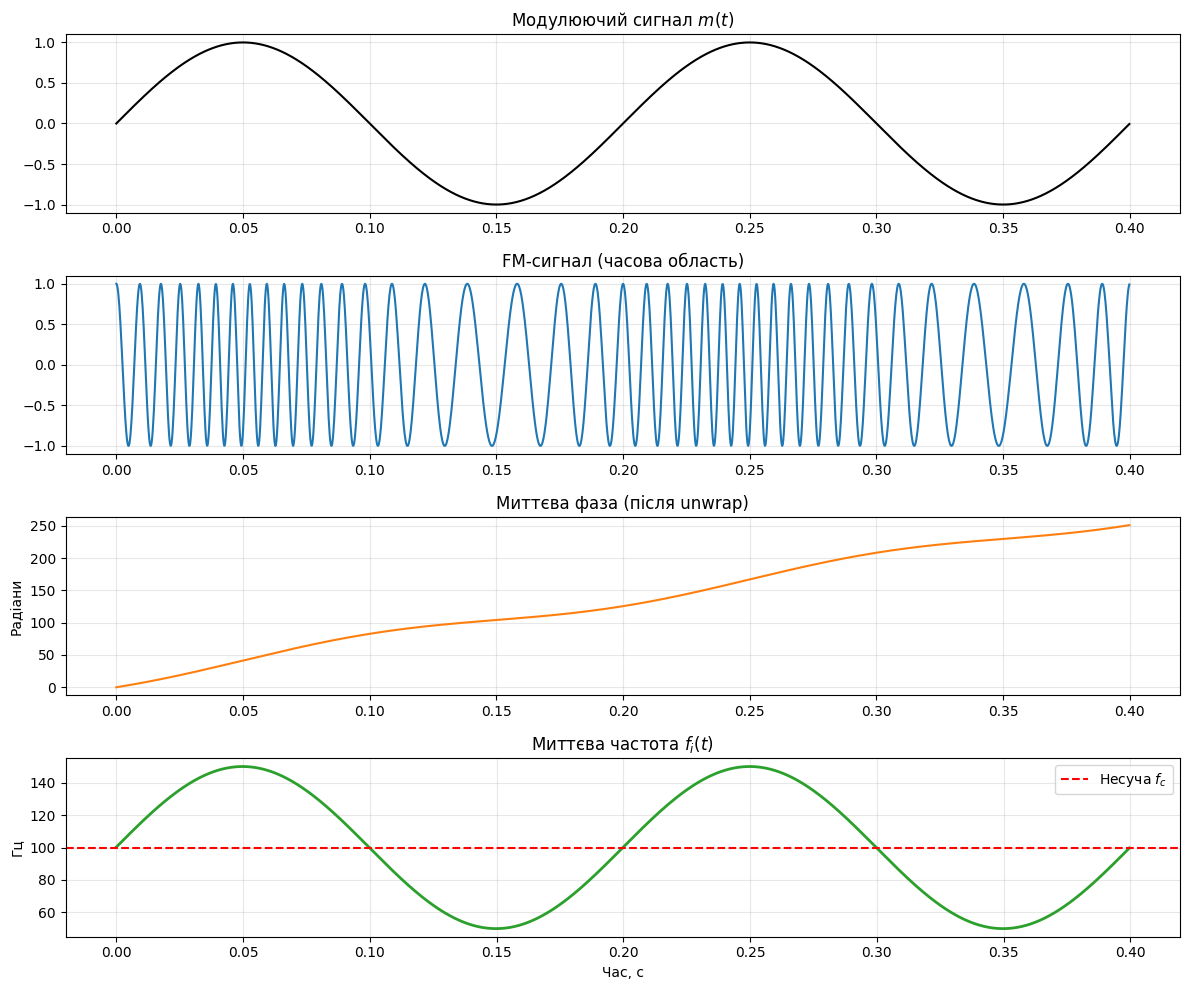

In [10]:
# 8.Побудувати графік миттєвої фази або миттєвої частоти для FM/PM-сигналу.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Параметри
fs = 5000
t = np.arange(0, 0.4, 1/fs)
fc = 100            # Несуча частота
fm = 5              # Частота повідомлення
kf = 50             # Девіація для FM

# Модулюючий сигнал
m = np.sin(2 * np.pi * fm * t)

# Генерація FM-сигналу
integral_m = np.cumsum(m) / fs
fm_sig = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# Виділення миттєвих характеристик через перетворення Гільберта
analytic_signal = hilbert(fm_sig)

# Миттєва фаза (розгорнута, щоб не було стрибків від -pi до pi)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))

# Миттєва частота (похідна від фази)
# f = (1/2pi) * d(phi)/dt
instantaneous_frequency = np.diff(instantaneous_phase) / (2.0 * np.pi * (1/fs))

# Візуалізація
plt.figure(figsize=(12, 10))

# Повідомлення
plt.subplot(4, 1, 1)
plt.plot(t, m, 'k')
plt.title("Модулюючий сигнал $m(t)$")
plt.grid(True, alpha=0.3)

# FM-сигнал
plt.subplot(4, 1, 2)
plt.plot(t, fm_sig, 'C0')
plt.title("FM-сигнал (часова область)")
plt.grid(True, alpha=0.3)

# Миттєва фаза
plt.subplot(4, 1, 3)
plt.plot(t, instantaneous_phase, 'C1')
plt.title("Миттєва фаза (після unwrap)")
plt.ylabel("Радіани")
plt.grid(True, alpha=0.3)

# Миттєва частота
plt.subplot(4, 1, 4)
plt.plot(t[:-1], instantaneous_frequency, 'C2', linewidth=2)
plt.axhline(y=fc, color='r', linestyle='--', label='Несуча $f_c$')
plt.title("Миттєва частота $f_i(t)$")
plt.ylabel("Гц")
plt.xlabel("Час, с")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Спостереження:**

Миттєва фаза: графік виглядає як пряма лінія, що йде вгору, але з невеликими хвилями. Пряма лінія – внесок несучої частоти, хвилі – корисна інформація, яка додається до фази.

Миттєва частота точно повторює форму моделюючого сигналу, коливається навколо значення несучої частоти (100Гц).Розмах частоти коливань – девіація частоти, яка визначається коефіцієнтом k_f.


**Висновки до лабораторної роботи:**

Глибина модуляції: для якісної передачі інформації коефіцієнт модуляції повинен задовольняти умову μ ≤ 1.

Спектральний аналіз: АМ є спектрально економною. При двотональному модулюванні спектр лінійно розширюється.

FM і PM є спорідненими видами модуляції, у PMфаза змінюється пропорційно повідомленню, а у FM – пропорційно його інтегралу.
